In [5]:
import pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv('../data/splits/train.csv')
df.replace('?', pd.NA, inplace=True)
df['readmitted_lt30'] = (df['readmitted'] == '<30').astype(int)

# Fill NaN BEFORE grouping so NotTested appears as its own bar
df['A1Cresult'] = df['A1Cresult'].fillna('NotTested')

label_map = {
    'NotTested': 'Not tested\n(83% of patients)',
    'Norm':      'Normal\n(HbA1c < 7%)',
    '>7':        'Elevated\n(HbA1c 7-8%)',
    '>8':        'High\n(HbA1c > 8%)'
}

a1c_rates = df.groupby('A1Cresult')['readmitted_lt30'].agg(['mean', 'count'])
# Order: NotTested first, then by ascending HbA1c level
a1c_rates = a1c_rates.reindex(['NotTested', 'Norm', '>7', '>8'])
labels = [label_map[idx] for idx in a1c_rates.index]
overall = df['readmitted_lt30'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#E24B4A' if idx == 'NotTested' else '#378ADD' for idx in a1c_rates.index]
bars = ax.bar(labels, a1c_rates['mean'] * 100, color=colors, width=0.5)
ax.axhline(overall * 100, color='gray', linestyle='--', linewidth=1.5)
ax.text(0.98, overall * 100 + 0.3, f'Overall mean {overall*100:.1f}%',
        color='gray', fontsize=8, va='bottom', ha='right',
        transform=ax.get_yaxis_transform())

for bar, (idx, row) in zip(bars, a1c_rates.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{row['mean']*100:.1f}%\nn={int(row['count']):,}",
            ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Patients readmitted within 30 days (%)')
ax.set_title('Early readmission rate by HbA1c test result')
ax.set_ylim(0, 16)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.tight_layout()
plt.savefig('a1c_readmission_rates.png', dpi=150)
plt.close()

# This was a sanity check to see if train.csv and test_github.csv contained any overlapping patients.

In [45]:
import pandas as pd

train = pd.read_csv('../data/splits/train.csv')
test = pd.read_csv('../data/splits/test_github.csv')

# Example: assume 'id' uniquely identifies encounters
overlap = set(train['id']) & set(test['id'])

print(f"Number of overlapping encounters: {len(overlap)}")

Number of overlapping encounters: 0


# This was a figure to show how we dropped some medications which were like used in less than 2% of the cases

/tmp/ipykernel_2426/3098613837.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(med_cols, rotation=45, ha='right', fontsize=8)


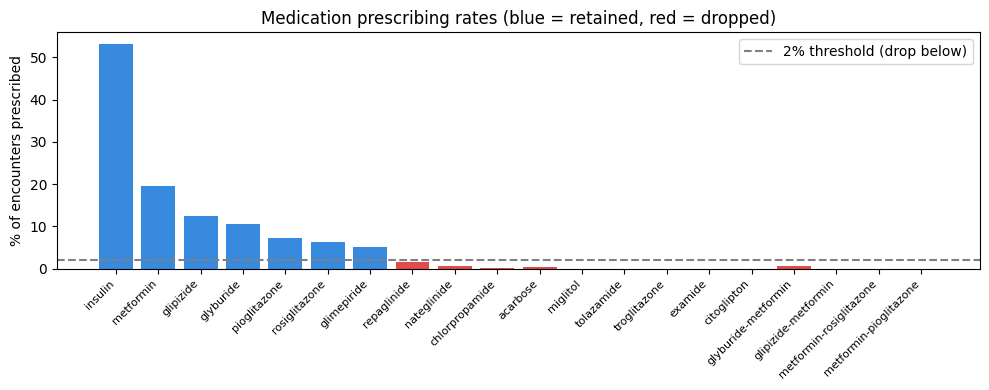

In [1]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv('../data/splits/train.csv')
med_cols = ['insulin','metformin','glipizide','glyburide','pioglitazone',
            'rosiglitazone','glimepiride','repaglinide','nateglinide',
            'chlorpropamide','acarbose','miglitol','tolazamide',
            'troglitazone','examide','citoglipton','glyburide-metformin',
            'glipizide-metformin','metformin-rosiglitazone','metformin-pioglitazone']
pct = [(df[c] != 'No').mean()*100 for c in med_cols]
colors = ['#378ADD' if p >= 2 else '#E24B4A' for p in pct]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(med_cols, pct, color=colors)
ax.axhline(2, color='gray', linestyle='--', label='2% threshold (drop below)')
ax.set_ylabel('% of encounters prescribed')
ax.set_xticklabels(med_cols, rotation=45, ha='right', fontsize=8)
ax.set_title('Medication prescribing rates (blue = retained, red = dropped)')
ax.legend()
plt.tight_layout()
plt.savefig('medication_rates.png', dpi=150)

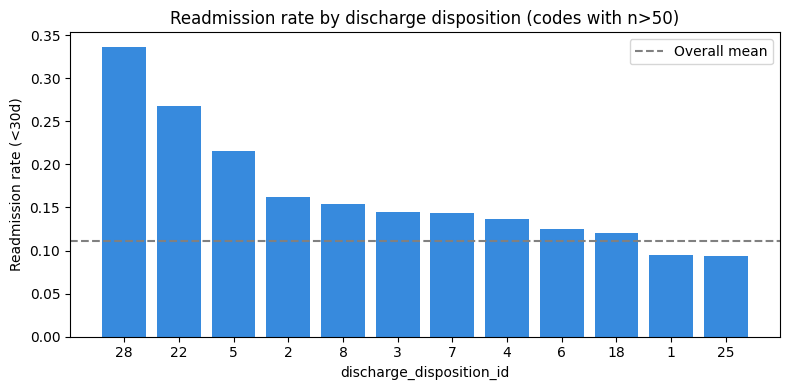

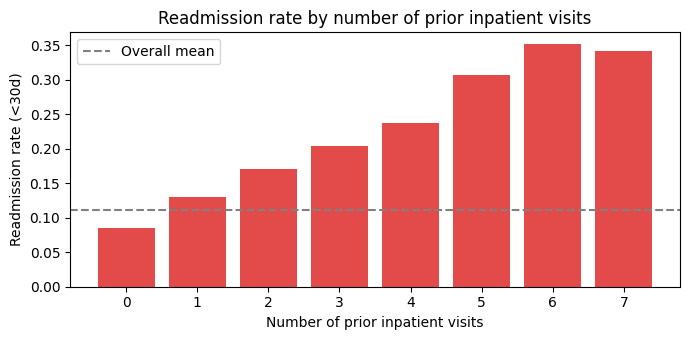

In [2]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv('../data/splits/train.csv')
df.replace('?', pd.NA, inplace=True)
df['readmitted_lt30'] = (df['readmitted'] == '<30').astype(int)
rates = df.groupby('discharge_disposition_id')['readmitted_lt30'].agg(['mean','count'])
rates = rates[rates['count'] > 50].sort_values('mean', ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rates.index.astype(str), rates['mean'], color='#378ADD')
ax.axhline(df['readmitted_lt30'].mean(), color='gray', linestyle='--', label='Overall mean')
ax.set_xlabel('discharge_disposition_id')
ax.set_ylabel('Readmission rate (<30d)')
ax.set_title('Readmission rate by discharge disposition (codes with n>50)')
ax.legend()
plt.tight_layout()
plt.savefig('discharge_disposition_rates.png', dpi=150)

rates2 = df[df['number_inpatient'] <= 7].groupby('number_inpatient')['readmitted_lt30'].agg(['mean','count'])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(rates2.index.astype(str), rates2['mean'], color='#E24B4A')
ax.axhline(df['readmitted_lt30'].mean(), color='gray', linestyle='--', label='Overall mean')
ax.set_xlabel('Number of prior inpatient visits')
ax.set_ylabel('Readmission rate (<30d)')
ax.set_title('Readmission rate by number of prior inpatient visits')
ax.legend()
plt.tight_layout()
plt.savefig('inpatient_rates.png', dpi=150)

# This should maybe be updated see the todo in latex in the section where this figure exists. like i don't know if this is a correct categorisation

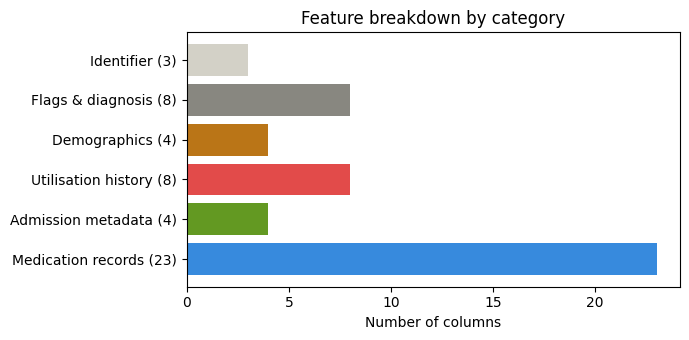

In [3]:
import matplotlib.pyplot as plt
categories = ['Medication records (23)', 'Admission metadata (4)',
              'Utilisation history (8)', 'Demographics (4)',
              'Flags & diagnosis (8)', 'Identifier (3)']
counts = [23, 4, 8, 4, 8, 3]
colors = ['#378ADD','#639922','#E24B4A','#BA7517','#888780','#D3D1C7']
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(categories, counts, color=colors)
ax.set_xlabel('Number of columns')
ax.set_title('Feature breakdown by category')
plt.tight_layout()
plt.savefig('feature_categories.png', dpi=150)

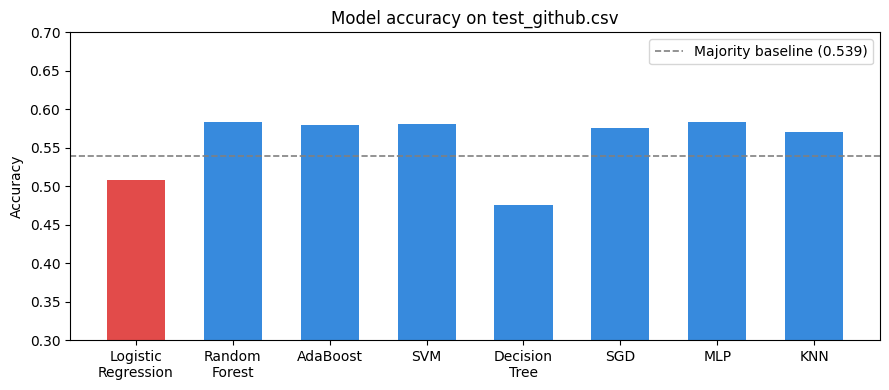

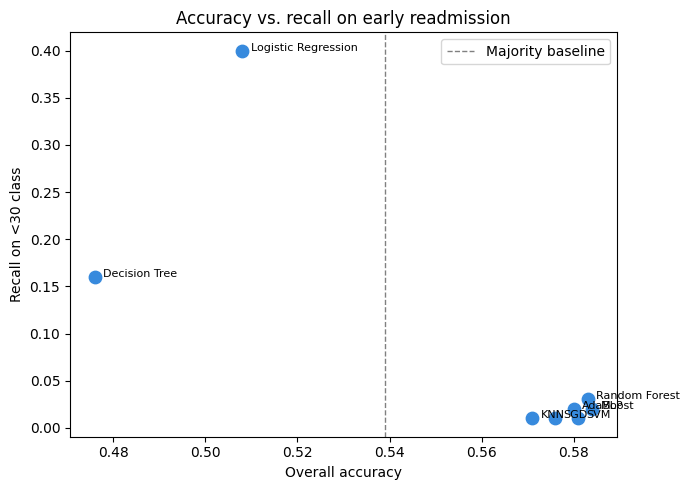

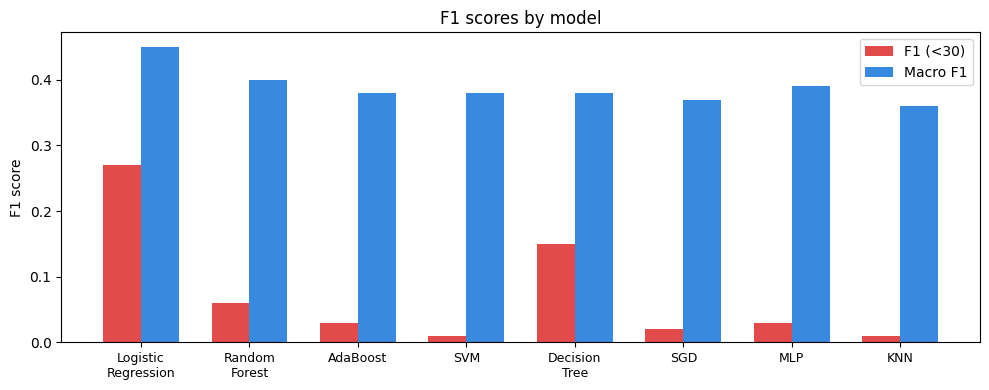

In [4]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic\nRegression', 'Random\nForest', 'AdaBoost', 'SVM', 
          'Decision\nTree', 'SGD', 'MLP', 'KNN']
accuracy = [0.508, 0.583, 0.580, 0.581, 0.476, 0.576, 0.584, 0.571]
recall_lt30 = [0.40, 0.03, 0.02, 0.01, 0.16, 0.01, 0.02, 0.01]
f1_lt30 = [0.27, 0.06, 0.03, 0.01, 0.15, 0.02, 0.03, 0.01]
macro_f1 = [0.45, 0.40, 0.38, 0.38, 0.38, 0.37, 0.39, 0.36]

# ── Figure 1: Accuracy vs majority baseline ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E24B4A' if m == 'Logistic\nRegression' else '#378ADD' for m in models]
ax.bar(models, accuracy, color=colors, width=0.6)
ax.axhline(0.539, color='gray', linestyle='--', linewidth=1.2, label='Majority baseline (0.539)')
ax.set_ylabel('Accuracy')
ax.set_title('Model accuracy on test_github.csv')
ax.set_ylim(0.3, 0.7)
ax.legend()
plt.tight_layout()
plt.savefig('model_accuracy.png', dpi=150)

# ── Figure 2: Accuracy vs Recall <30 trade-off ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(accuracy, recall_lt30, s=80, color='#378ADD', zorder=3)
for i, m in enumerate(models):
    ax.annotate(m.replace('\n', ' '), (accuracy[i], recall_lt30[i]),
                textcoords='offset points', xytext=(6, 0), fontsize=8)
ax.set_xlabel('Overall accuracy')
ax.set_ylabel('Recall on <30 class')
ax.set_title('Accuracy vs. recall on early readmission')
ax.axvline(0.539, color='gray', linestyle='--', linewidth=1, label='Majority baseline')
ax.legend()
plt.tight_layout()
plt.savefig('accuracy_vs_recall.png', dpi=150)

# ── Figure 3: F1 comparison ───────────────────────────────────────────────────
x = np.arange(len(models))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, f1_lt30,  w, label='F1 (<30)',     color='#E24B4A')
ax.bar(x + w/2, macro_f1, w, label='Macro F1',     color='#378ADD')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel('F1 score')
ax.set_title('F1 scores by model')
ax.legend()
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)

# Preprocessing pipeline (NOTE THAT SOME OF THE STEPS ARE NOT PERFORMED, SEE THE FUNCTION "def preprocess(df)" lower down to actually see which are used (we dont use does that remove rows basically, we need to motivate this in the paper there is a todo))
This is the entire preprocessing, it should be done in this order aswell. We are constantly referencing "the paper" which is to be understood as this paper: https://onlinelibrary.wiley.com/doi/10.1155/2014/781670


## Setup
Read the dataset and define our target

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
TARGET = "readmitted"

## Step 1: Remove exact duplicate rows
Actually there are none in this dataset but whatever.

In [6]:
def step_1(df):
    df = df.drop_duplicates()
    return df

## Step 2: Keep only the first encounter per patient
Thise is an idea directly stolen from the paper; they explain how keeping multiple encounters from the same patient violates the independence assumption of most classifiers and causes data leakage between train/test

In [7]:
def step_2(df):
    df.sort_values('encounter_id', inplace=True)
    df.drop_duplicates(subset='patient_nbr', keep='first', inplace=True)
    return df

## Step 3: Remove encounters that ended in death or discharge to hospice
Another idea directly stolen from the paper; they explain how a patient who died cannot be readmitted,
so including them would distort the readmission. Sounds very reasonable

In [8]:
def step_3(df):
    # discharge_disposition_id values per IDS_mapping.csv:
    #   11 = Expired
    #   13 = Hospice / home
    #   14 = Hospice / medical facility
    #   19 = Expired at home (Medicaid/hospice)
    #   20 = Expired in a medical facility (Medicaid/hospice)
    #   21 = Expired, place unknown (Medicaid/hospice)
    HOSPICE_DEATH_IDS = [11, 13, 14, 19, 20, 21]
    df = df[~df['discharge_disposition_id'].isin(HOSPICE_DEATH_IDS)]
    return df

## Step 4: Encode the target variable as binary
This Step could be done in two different ways, either encode '<30' and '>30' as 1 and 'No' as 0, or have only '<30' as 1, and '>30' and 'No' as 0. The paper used the later; explaining how early readmission (<30 days) is the clinically critical outcome.

In [9]:
def step_4(df):
    df[TARGET] = df[TARGET].map(lambda x: 1 if x == '<30' else 0)
    print("Target distribution:\n", df[TARGET].value_counts(normalize=True))
    return df

## Step 5: Drop identifier columns
These columns are just identifiers, there is no predictive value for them.

In [10]:
def step_5(df):
    IDENTIFIER_COLS = ["id", "encounter_id", "patient_nbr"]
    df.drop(columns=IDENTIFIER_COLS, inplace=True)
    return df

## Step 6: Replace '?' sentinel with proper NaN
Several numerical columns use '?' to denote missing values instead of a NaN.

In [11]:
def step_6(df):
    df.replace('?', pd.NA, inplace=True)
    return df

In [12]:
def step_6b(df):
    # discharge_disposition_id has enormous signal — readmission rates range
    # from 0% (hospice/death — patient can't return) to 40%+ (transferred to
    # another acute facility, suggesting ongoing serious illness).
    # Grouping into 4 risk buckets is more informative than 26 OHE columns.
    HIGH_RISK    = [22, 5, 2, 9, 15, 28]   # rehab, transfers, inpatient: 16-40%
    MEDIUM_RISK  = [3, 4, 24, 8, 7]         # SNF, ICF, other: 10-16%
    LOW_RISK     = [1, 6, 25]               # home, home+care: 7-13%
    ZERO_RISK    = [11, 13, 14, 19, 20, 21] # hospice/death: 0% (can't return)
    # Anything else → Medium as default

    def map_discharge(val):
        if val in HIGH_RISK:   return 'HighRisk'
        if val in ZERO_RISK:   return 'HospiceDeath'
        if val in LOW_RISK:    return 'LowRisk'
        return 'MediumRisk'

    df['discharge_disposition_id'] = df['discharge_disposition_id'].map(map_discharge)
    return df

## Step 7: Drop columns with >10% missing data (except those with clinical justification)
A feature with >10% missing values risks introducing systematic bias during
imputation. We drop weight (97% missing) altough this probably clinically relevant there is simply not enough data, if i remember correctly it was not required to take records of weights before 2009.
The payer_code payer_code (52% missing) was also removed since it has no clinical relevance.
*Exception*: medical_specialty, A1Cresult, and max_glu_serum are excluded from this drop see Step 8.

In [13]:
def step_7(df):
    # weight (97% missing)
    # payer_code (52% missing)
    MANUALLY_DROPPED = ['weight', 'payer_code', 'race']
    df.drop(columns=MANUALLY_DROPPED, inplace=True)
    return df

## Step 8: Handle A1Cresult, max_glu_serum, and medical_specialty
These columns are ~83%, ~95%, and ~50% missing respectively, which would normally trigger removal. However, the paper's central finding is that the actually meassuring HbA1c is itself a significant predictor of readmission
Missingness is therefore informative.
We encode "not tested" as its own category rather than discarding the feature.

The paper also explicitly kept medical_specialty explaining; how a physician's specialty is a meaningful clinical signal for how diabetes is managed. 

In [14]:
def step_8(df):
    df['A1Cresult']         = df['A1Cresult'].fillna('NotTested')
    df['max_glu_serum']     = df['max_glu_serum'].fillna('NotTested')
    df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
    return df

In [15]:
def step_8b(df):
    # Keep only specialties covering >1% of patients, collapse rest to 'Other'
    # This reduces 68 OHE columns to ~10 meaningful ones
    top_specialties = df['medical_specialty'].value_counts(normalize=True)
    top_specialties = top_specialties[top_specialties >= 0.01].index.tolist()
    df['medical_specialty'] = df['medical_specialty'].apply(
        lambda x: x if x in top_specialties else 'Other'
    )
    return df

## Step 9: Drop zero-variance columns
Columns where every row has the same value contribute zero information.
In this dataset, 'examide' and 'citoglipton' are always 'No'.

In [16]:
def step_9(df):
    nzv_cols = [
        col for col in df.columns
        if col != TARGET and df[col].value_counts(normalize=True).iloc[0] >= 0.98
    ]
    print(f"Near-zero-variance columns dropped: {nzv_cols}")
    df.drop(columns=nzv_cols, inplace=True)
    return df

## Step 10: Map ICD-9 diagnosis codes to clinical categories
diag_1/2/3 each have ~850-950 unique raw ICD-9 codes. The paper maps them to 9 clinically meaningful
groups, which reduces dimensionality.

In [17]:
def map_icd9_to_category(code):
    if pd.isna(code):
        return 'Other'
    try:
        c = float(code)
    except ValueError:
        return 'Other'  # E-codes, V-codes → Other
    if 390 <= c <= 459 or c == 785: return 'Circulatory'
    if 460 <= c <= 519 or c == 786: return 'Respiratory'
    if 520 <= c <= 579 or c == 787: return 'Digestive'
    if 250 <= c < 251:              return 'Diabetes'
    if 800 <= c <= 999:             return 'Injury'
    if 710 <= c <= 739:             return 'Musculoskeletal'
    if 580 <= c <= 629 or c == 788: return 'Genitourinary'
    if 140 <= c <= 239:             return 'Neoplasms'
    return 'Other'

def step_10(df):
    for col in ['diag_1', 'diag_2', 'diag_3']:
        df[col] = df[col].apply(map_icd9_to_category)
    return df

## Step 11: Encode age as 3 ordered groups
Idea directly stolen from the paper, instead of assigning a numerical value to each age span, they encoded ages as three groups, young, medium, senior.

In [18]:
def map_age_to_group(age_bracket):
    young = ['[0-10)', '[10-20)', '[20-30)']
    middle = ['[30-40)', '[40-50)', '[50-60)']
    if age_bracket in young:   return 'Young'       # [0, 30)
    if age_bracket in middle:  return 'Middle'      # [30, 60)
    return 'Senior'                                 # [60, 100+)

def step_11(df):
    df['age'] = df['age'].map(map_age_to_group)
    return df

## Step 12: Encode medication columns and engineer aggregate features
All 23 medication columns use values No/Steady/Up/Down. We encode them ordinally (0=not prescribed, 1=steady, 2=down, 3=up) to preserve the direction of dosage change, which is clinically relevant acording to the paper

In [19]:
def step_12(df):
    MED_COLS = [
        'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
        'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
        'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
        'miglitol', 'troglitazone', 'tolazamide', 'insulin',
        'glyburide-metformin', 'glipizide-metformin',
        'glimepiride-pioglitazone', 'metformin-rosiglitazone',
        'metformin-pioglitazone'
    ]

    # Zero-variance are already dropped)
    MED_COLS = [c for c in MED_COLS if c in df.columns]
    MED_MAP = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

    for col in MED_COLS:
        df[col] = df[col].map(MED_MAP)
    return df

In [20]:
def step_12b(df):
    # number_inpatient has the strongest signal in the dataset.
    # Readmission rate: 0 visits = 8.3%, 1 visit = 12.9%, 3+ visits = 25%+
    # A simple binary flag captures this threshold effect cleanly.
    if 'number_inpatient' in df.columns:
        df['has_prior_inpatient'] = (df['number_inpatient'] > 0).astype(int)
    if 'number_emergency' in df.columns:
        df['has_prior_emergency'] = (df['number_emergency'] > 0).astype(int)
    return df

## Step 13: Handle missing values in race
After all steps above, only 'race' retains a small number of NaNs (~2%). The paper treats 'Missing' race as its own category, noting it actually had the lowest readmission rate (7.5%).

In [21]:
""" def step_13(df):
    df['race'] = df['race'].fillna('Unknown')
    return df """

" def step_13(df):\n    df['race'] = df['race'].fillna('Unknown')\n    return df "

## Step 14: Train / test split
This must happen before doing things like one-hot encoding or scaling numerical values for logistic regression.

In [22]:
def step_14(df):
    X = df.drop(columns=[TARGET])
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
    return X_train, X_test, y_train, y_test

## Step 15a: One hot encoding

In [23]:
def step_15a(X_train, X_test):
    CATEGORICAL_COLS = [
        'race', 'gender', 'age', 'change', 'diabetesMed',
        'diag_1', 'diag_2', 'diag_3',
        'A1Cresult', 'max_glu_serum', 'medical_specialty',
        'admission_type_id', 'discharge_disposition_id', 'admission_source_id'
    ]

    # Maybe a column has are already dropped
    CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in X_train.columns]

    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    ohe.fit(X_train[CATEGORICAL_COLS])  # fit on train only

    train_cat = pd.DataFrame(
        ohe.transform(X_train[CATEGORICAL_COLS]),
        columns=ohe.get_feature_names_out(CATEGORICAL_COLS),
        index=X_train.index
    )
    test_cat = pd.DataFrame(
        ohe.transform(X_test[CATEGORICAL_COLS]),
        columns=ohe.get_feature_names_out(CATEGORICAL_COLS),
        index=X_test.index
    )

    X_train = pd.concat([X_train.drop(columns=CATEGORICAL_COLS), train_cat], axis=1)
    X_test  = pd.concat([X_test.drop(columns=CATEGORICAL_COLS),  test_cat],  axis=1)
    return X_train, X_test

## Step 16: Scaling

In [24]:
def step_16(X_train, X_test):
    NUMERICAL_COLS = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient', 'number_diagnoses'
    ]
    
    # Maybe a column has are already dropped
    NUMERICAL_COLS = [c for c in NUMERICAL_COLS if c in X_train.columns]
    
    scaler = StandardScaler()
    scaler.fit(X_train[NUMERICAL_COLS])  # fit on train only
    X_train[NUMERICAL_COLS] = scaler.transform(X_train[NUMERICAL_COLS])
    X_test[NUMERICAL_COLS]  = scaler.transform(X_test[NUMERICAL_COLS])

    return X_train, X_test

# Preprocessing pipeline as a function
We have defined every step of the pipeline as a function. 
Now we build entire pipeline as a function so that we can very simply call it

In [25]:
def preprocess(df):
    df = step_1(df)
    df = step_5(df)
    df = step_6(df)
    df = step_6b(df)   # NEW — group discharge_disposition_id
    df = step_7(df)
    df = step_8(df)
    df = step_8b(df)   # NEW — collapse rare medical specialties
    df = step_9(df)    # UPDATED — near-zero variance threshold
    df = step_10(df)
    df = step_11(df)
    df = step_12(df)
    df = step_12b(df)  # NEW — binary flags for inpatient/emergency history
    #df = step_13(df)
    return df

In [26]:
def one_hot_encoding_and_scaling(X_train, X_test):
    X_train, X_test = step_15a(X_train, X_test)
    X_train, X_test = step_16(X_train, X_test)
    return X_train, X_test

# Model Selection
We train on the full `train.csv` and evaluate on `test_github.csv` as a held-out test set.
This is the correct setup — no artificial splitting of training data.

The target is kept as 3 classes (`No`, `>30`, `<30`) to match the Kaggle task.
`class_weight='balanced'` is used to ensure the model does not ignore the minority class `<30`.

## Shared setup — run this cell first

In [27]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Load and preprocess
train_df = preprocess(pd.read_csv("../data/splits/train.csv"))
test_df  = preprocess(pd.read_csv("../data/splits/test_github.csv"))

# Separate features and target (keep 3-class target)
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

print("Train:", X_train.shape, "| Target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest:", X_test.shape, "| Target distribution:")
print(y_test.value_counts(normalize=True).round(3))


Near-zero-variance columns dropped: ['repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Near-zero-variance columns dropped: ['repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Train: (71236, 30) | Target distribution:
readmitted
No     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64

Test: (15265, 30) | Target distribution:
readmitted
No     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64


In [28]:
# Fit OHE and scaler on training data only
CATEGORICAL_COLS = [c for c in [
    'race', 'gender', 'age', 'change', 'diabetesMed',
    'diag_1', 'diag_2', 'diag_3', 'A1Cresult', 'max_glu_serum',
    'medical_specialty', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id'
] if c in X_train.columns]

NUMERICAL_COLS = [c for c in [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
] if c in X_train.columns]

ohe_eval = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_eval.fit(X_train[CATEGORICAL_COLS])

scaler_eval = StandardScaler()
scaler_eval.fit(X_train[NUMERICAL_COLS])

def apply_encoding(X, ohe, scaler, cat_cols, num_cols, reference_cols):
    cat = pd.DataFrame(ohe.transform(X[cat_cols]),
                       columns=ohe.get_feature_names_out(cat_cols),
                       index=X.index)
    X = pd.concat([X.drop(columns=cat_cols), cat], axis=1)
    X[num_cols] = scaler.transform(X[num_cols])
    return X.reindex(columns=reference_cols, fill_value=0)

# Encode train
X_train_enc = apply_encoding(X_train, ohe_eval, scaler_eval, CATEGORICAL_COLS, NUMERICAL_COLS, None)
reference_cols = X_train_enc.columns

# Encode test using same fitted transformers
X_test_enc = apply_encoding(X_test, ohe_eval, scaler_eval, CATEGORICAL_COLS, NUMERICAL_COLS, reference_cols)

print(f"Features after encoding: {X_train_enc.shape[1]}")


Features after encoding: 102


## Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_train_enc, y_train)
y_pred_lr = clf.predict(X_test_enc)

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))


Logistic Regression
Accuracy: 0.5084
              precision    recall  f1-score   support

         <30       0.20      0.40      0.27      1704
         >30       0.47      0.40      0.43      5332
          No       0.68      0.60      0.64      8229

    accuracy                           0.51     15265
   macro avg       0.45      0.47      0.45     15265
weighted avg       0.55      0.51      0.52     15265



## Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=1)
clf.fit(X_train_enc, y_train)
y_pred_rf = clf.predict(X_test_enc)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))


Random Forest
Accuracy: 0.5830
              precision    recall  f1-score   support

         <30       0.51      0.03      0.06      1704
         >30       0.49      0.40      0.44      5332
          No       0.62      0.82      0.71      8229

    accuracy                           0.58     15265
   macro avg       0.54      0.42      0.40     15265
weighted avg       0.56      0.58      0.54     15265



## AdaBoost

In [31]:
from sklearn.ensemble import AdaBoostClassifier

clf = AdaBoostClassifier(n_estimators=300, random_state=42)
clf.fit(X_train_enc, y_train)
y_pred_ada = clf.predict(X_test_enc)

print("Ada boost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")
print(classification_report(y_test, y_pred_ada))

Ada boost
Accuracy: 0.5800
              precision    recall  f1-score   support

         <30       0.40      0.02      0.03      1704
         >30       0.49      0.34      0.40      5332
          No       0.61      0.86      0.71      8229

    accuracy                           0.58     15265
   macro avg       0.50      0.40      0.38     15265
weighted avg       0.54      0.58      0.53     15265



## Support Vector machines

In [32]:
from sklearn.svm import LinearSVC

clf = LinearSVC(random_state=42)
clf.fit(X_train_enc, y_train)
y_pred_svm = clf.predict(X_test_enc)

print("Support Vector machines")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))

Support Vector machines
Accuracy: 0.5812
              precision    recall  f1-score   support

         <30       0.46      0.01      0.01      1704
         >30       0.49      0.35      0.41      5332
          No       0.61      0.85      0.71      8229

    accuracy                           0.58     15265
   macro avg       0.52      0.40      0.38     15265
weighted avg       0.55      0.58      0.53     15265



## Decistion Tree

In [33]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_enc, y_train)
y_pred_dt = clf.predict(X_test_enc)

print("Decision Tree")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.4761
              precision    recall  f1-score   support

         <30       0.15      0.16      0.15      1704
         >30       0.40      0.41      0.40      5332
          No       0.60      0.59      0.60      8229

    accuracy                           0.48     15265
   macro avg       0.38      0.38      0.38     15265
weighted avg       0.48      0.48      0.48     15265



## SGD


In [34]:
from sklearn.linear_model import SGDClassifier

clf = SGDClassifier()
clf.fit(X_train_enc, y_train)
y_pred_sgd = clf.predict(X_test_enc)

print("Stochastic GD")
print(f"Accuracy: {accuracy_score(y_test, y_pred_sgd):.4f}")
print(classification_report(y_test, y_pred_sgd))

Stochastic GD
Accuracy: 0.5775
              precision    recall  f1-score   support

         <30       0.00      0.00      0.00      1704
         >30       0.48      0.37      0.42      5332
          No       0.61      0.83      0.71      8229

    accuracy                           0.58     15265
   macro avg       0.36      0.40      0.37     15265
weighted avg       0.50      0.58      0.53     15265



## Multi-layer percepton

In [35]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(max_iter=400, solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1)
clf.fit(X_train_enc, y_train)
y_pred_mlp = clf.predict(X_test_enc)

print("Multi-layer percepton")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))

Multi-layer percepton
Accuracy: 0.5841
              precision    recall  f1-score   support

         <30       0.35      0.02      0.03      1704
         >30       0.50      0.38      0.43      5332
          No       0.62      0.83      0.71      8229

    accuracy                           0.58     15265
   macro avg       0.49      0.41      0.39     15265
weighted avg       0.55      0.58      0.54     15265



/home/sebl2227/uu/ml/project/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


## K-Nearest Neighbours

In [36]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=100)
clf.fit(X_train_enc, y_train)
y_pred_knn = clf.predict(X_test_enc)

print("K-Nearest Neighbours")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbours
Accuracy: 0.5711
              precision    recall  f1-score   support

         <30       0.44      0.01      0.01      1704
         >30       0.48      0.28      0.35      5332
          No       0.59      0.88      0.71      8229

    accuracy                           0.57     15265
   macro avg       0.51      0.39      0.36     15265
weighted avg       0.54      0.57      0.51     15265



# En confusion matrix som används i rapporten, säkerställ att vi skriver om den och refererar den.

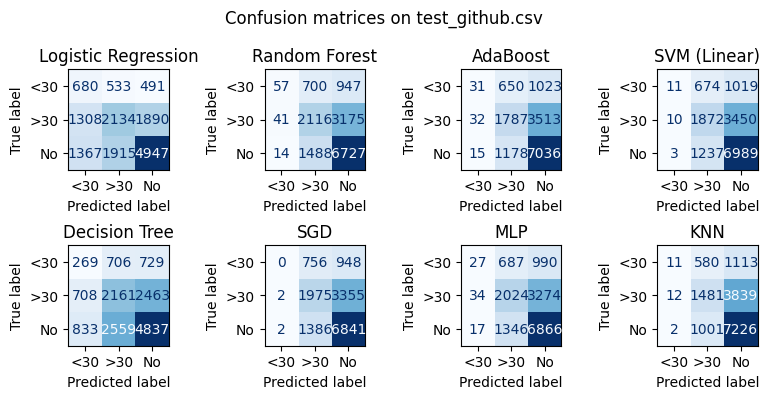

In [40]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# (run after fitting models and getting y_pred_lr, y_pred_rf, y_pred_dt)
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
models_preds = [('Logistic Regression', y_pred_lr),
                ('Random Forest', y_pred_rf),
                ('AdaBoost', y_pred_ada),
                ('SVM (Linear)', y_pred_svm),
                ('Decision Tree', y_pred_dt),
                ('SGD', y_pred_sgd),
                ('MLP', y_pred_mlp),
                ('KNN', y_pred_knn),]
for ax, (name, y_pred) in zip(axes.flatten(), models_preds):
    cm = confusion_matrix(y_test, y_pred, labels=['<30','>30','No'])
    ConfusionMatrixDisplay(cm, display_labels=['<30','>30','No']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion matrices on test_github.csv', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)

# Kaggle Submission (kolla rad 22 där är modellen man väljer för att göra predictions på kaggle )
We train on all of `train.csv` and predict on `test.csv`.
The same `preprocess()` function is used on both — identical steps, consistent distribution.
`test.csv` has no `readmitted` column so no step_4.

In [41]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Preprocess train (same function as model selection)
train_df = preprocess(pd.read_csv("../data/splits/train.csv"))
X_all    = train_df.drop(columns=[TARGET])
y_all    = train_df[TARGET]

# Fit OHE and scaler on all training data
ohe_final    = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler_final = StandardScaler()

ohe_final.fit(X_all[CATEGORICAL_COLS])
scaler_final.fit(X_all[NUMERICAL_COLS])

train_cat = pd.DataFrame(ohe_final.transform(X_all[CATEGORICAL_COLS]),
                         columns=ohe_final.get_feature_names_out(CATEGORICAL_COLS),
                         index=X_all.index)
X_all_enc = pd.concat([X_all.drop(columns=CATEGORICAL_COLS), train_cat], axis=1)
X_all_enc[NUMERICAL_COLS] = scaler_final.transform(X_all_enc[NUMERICAL_COLS])

# Train model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_all_enc, y_all)

print("Model trained. Classes:", model.classes_)
print("Training distribution:")
print(y_all.value_counts(normalize=True).round(3))


Near-zero-variance columns dropped: ['repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Model trained. Classes: ['<30' '>30' 'No']
Training distribution:
readmitted
No     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64


In [42]:
# Preprocess test.csv — same preprocess() function, save IDs before step_5 drops them
test_raw   = pd.read_csv("../data/splits/test.csv")
kaggle_ids = test_raw['id'].copy()

test_df    = preprocess(test_raw)
X_kaggle   = test_df  # no readmitted column so nothing to drop

# Apply same fitted transformers
kaggle_cat = pd.DataFrame(ohe_final.transform(X_kaggle[CATEGORICAL_COLS]),
                           columns=ohe_final.get_feature_names_out(CATEGORICAL_COLS),
                           index=X_kaggle.index)
X_kaggle_enc = pd.concat([X_kaggle.drop(columns=CATEGORICAL_COLS), kaggle_cat], axis=1)
X_kaggle_enc[NUMERICAL_COLS] = scaler_final.transform(X_kaggle_enc[NUMERICAL_COLS])
X_kaggle_enc = X_kaggle_enc.reindex(columns=X_all_enc.columns, fill_value=0)

# Predict
y_pred = model.predict(X_kaggle_enc)

print(f"Rows: {len(y_pred)}")
print(pd.Series(y_pred).value_counts())


Near-zero-variance columns dropped: ['repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Rows: 15265
No     7328
>30    4545
<30    3392
Name: count, dtype: int64


In [43]:
submission = pd.DataFrame({
    'id':         kaggle_ids.values,
    'readmitted': y_pred
})
submission.to_csv("../kaggle_submission.csv", index=False)
print(f"Saved kaggle_submission.csv — {len(submission)} rows")
print(submission.head())


Saved kaggle_submission.csv — 15265 rows
      id readmitted
0  47718        >30
1  84217         No
2  69573         No
3  33130        >30
4  49404        >30
